<a href="https://colab.research.google.com/github/AliAI11/DeepLens/blob/main/notebooks/03_explanation_generation_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# installing packages
!pip install -q transformers accelerate qwen-vl-utils torch torchvision pillow tqdm pandas numpy matplotlib scipy huggingface_hub

In [6]:
# imports and seeds
import os
import json
import zipfile
import random
import gc
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from transformers import (
    ViTForImageClassification,
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    AutoTokenizer,
    AutoModelForCausalLM,
)
from qwen_vl_utils import process_vision_info
from huggingface_hub import snapshot_download
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')
print(f'gpu: {torch.cuda.get_device_name(0) if device == "cuda" else "n/a"}')

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f'gpu memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

device: cuda
gpu: NVIDIA A100-SXM4-40GB


In [3]:
from google.colab import files

os.makedirs('./data', exist_ok=True)
os.makedirs('./models', exist_ok=True)

print('upload these files:')
print('  - splits.csv')
print('  - dataset_config.json')
print('  - test_predictions.csv')
print('  - test_attention_maps.npy')
print('  - vit_deepfake.zip')

uploaded = files.upload()

for fname in uploaded.keys():
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall('./models/vit_deepfake')
        os.remove(fname)
    else:
        os.rename(fname, f'./data/{fname}')

print('upload complete')

upload these files:
  - splits.csv
  - dataset_config.json
  - test_predictions.csv
  - test_attention_maps.npy
  - vit_deepfake.zip


Saving dataset_config.json to dataset_config.json
Saving splits.csv to splits.csv
Saving test_attention_maps.npy to test_attention_maps.npy
Saving test_predictions.csv to test_predictions.csv
Saving vit_deepfake.zip to vit_deepfake.zip
upload complete


In [7]:
# re-download shard_0
os.makedirs('./ntire_train', exist_ok=True)

print('downloading shard_0.zip...')
snapshot_download(
    repo_id="deepfakesMSU/NTIRE-RobustAIGenDetection-train",
    repo_type="dataset",
    allow_patterns=["shard_0.zip"],
    local_dir="./ntire_train"
)

print('extracting...')
with zipfile.ZipFile('./ntire_train/shard_0.zip', 'r') as z:
    z.extractall('./ntire_train')
os.remove('./ntire_train/shard_0.zip')

images_dir = './ntire_train/shard_0/images'
print(f'{len(os.listdir(images_dir))} images extracted')

downloading shard_0.zip...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

extracting...
50000 images extracted


In [11]:
# pick 100 highest-confidence fakes
test_preds = pd.read_csv('./data/test_predictions.csv')
attention_maps = np.load('./data/test_attention_maps.npy')

correct_fake = test_preds[(test_preds['label'] == 1) & (test_preds['pred_label'] == 1)].copy()
correct_fake = correct_fake.sort_values('pred_prob_fake', ascending=False).reset_index(drop=False)
correct_fake = correct_fake.rename(columns={'index': 'test_idx'})

N_EXPLAIN = 100
explain_subset = correct_fake.head(N_EXPLAIN).reset_index(drop=True)
print(f'using top-{N_EXPLAIN} highest-confidence fakes')

using top-100 highest-confidence fakes


In [12]:
def attention_to_text(attn_map_14x14):
    h, w = attn_map_14x14.shape
    regions = {
        'upper-left':   attn_map_14x14[:h//3, :w//3].mean(),
        'upper-center': attn_map_14x14[:h//3, w//3:2*w//3].mean(),
        'upper-right':  attn_map_14x14[:h//3, 2*w//3:].mean(),
        'middle-left':  attn_map_14x14[h//3:2*h//3, :w//3].mean(),
        'center':       attn_map_14x14[h//3:2*h//3, w//3:2*w//3].mean(),
        'middle-right': attn_map_14x14[h//3:2*h//3, 2*w//3:].mean(),
        'lower-left':   attn_map_14x14[2*h//3:, :w//3].mean(),
        'lower-center': attn_map_14x14[2*h//3:, w//3:2*w//3].mean(),
        'lower-right':  attn_map_14x14[2*h//3:, 2*w//3:].mean(),
    }
    sorted_regions = sorted(regions.items(), key=lambda x: -x[1])
    top2 = [r[0] for r in sorted_regions[:2]]
    return f'the {top2[0]} and {top2[1]} regions of the image'

print(f'sample: {attention_to_text(attention_maps[explain_subset.iloc[0]["test_idx"]])}')

sample: the upper-left and center regions of the image


In [13]:
# four prompt strategies
PROMPTS = {
    'zero_shot': """This image has been classified as AI-generated. Briefly describe the visual artifacts that suggest it is fake.""",

    'cot': """This image has been classified as AI-generated. Think step by step about what visual cues suggest it is fake. First identify the most suspicious regions, then describe specific artifacts you observe (skin texture, lighting, blending, backgrounds), then conclude with the strongest evidence.""",

    'few_shot': """This image has been classified as AI-generated. Common artifacts in AI-generated images include:
- Unnaturally smooth skin lacking pores or fine texture
- Lighting inconsistencies (e.g., highlights and shadows that disagree about the light source)
- Blending errors at boundaries (hair, jawline, edges of objects)
- Repetitive or warped patterns in backgrounds
- Asymmetric or malformed details (eyes, teeth, fingers, jewelry)

Identify which of these artifacts (if any) are present in this image and describe specifically where you see them.""",

    'attention_grounded': """This image has been classified as AI-generated. Our detector model focused most strongly on {region_text}. Examine those regions carefully and describe the specific visual artifacts (skin texture, lighting, blending, patterns, asymmetries) that suggest the image is AI-generated. Be specific about what you observe and where."""
}

print(f'defined {len(PROMPTS)} prompts: {list(PROMPTS.keys())}')

defined 4 prompts: ['zero_shot', 'cot', 'few_shot', 'attention_grounded']


In [19]:
# load Qwen-VL
print('loading qwen2.5-vl-7b-instruct...')
qwen_vl = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)
qwen_vl_processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
qwen_vl.eval()
qwen_vl_processor.tokenizer.padding_side = 'left'
print(f'loaded, gpu memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

loading qwen2.5-vl-7b-instruct...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

loaded, gpu memory: 35.07 GB


In [20]:
# explanation generator
def generate_explanation(image_path, prompt_text):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image_path},
        {"type": "text", "text": prompt_text}
    ]}]
    text = qwen_vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = qwen_vl_processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(qwen_vl.device)
    with torch.no_grad():
        gen_ids = qwen_vl.generate(**inputs, max_new_tokens=200, do_sample=False)
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    return qwen_vl_processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

sample_path = os.path.join(images_dir, explain_subset.iloc[0]['image_name'])
print(generate_explanation(sample_path, PROMPTS['zero_shot'])[:500])

The image appears to be AI-generated due to several visual artifacts:

1. **Blurred Background**: The background is out of focus, which can sometimes occur in AI-generated images where the depth of field is not accurately rendered.
2. **Lighting and Shadows**: The lighting on the person's face and the popcorn container seems inconsistent with natural lighting, which might indicate artificial rendering.
3. **Skin Texture**: The skin texture looks slightly unnatural, with some areas appearing smoo


In [21]:
# generate all 400 explanations
import os

ckpt_path = './data/explanations.csv'

# resume from checkpoint if exists
if os.path.exists(ckpt_path):
    expl_df = pd.read_csv(ckpt_path)
    done_names = set(expl_df['image_name'].tolist())
    all_explanations = expl_df.to_dict('records')
    print(f'resuming: {len(done_names)} images already done')
else:
    all_explanations = []
    done_names = set()

def generate_batch(image_path, prompts_list):
    """encode image once, generate all prompts in a single batched call"""
    messages_batch = [[{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": p}
        ]
    }] for p in prompts_list]

    texts = [qwen_vl_processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
             for m in messages_batch]
    image_inputs, video_inputs = process_vision_info(messages_batch)

    inputs = qwen_vl_processor(
        text=texts, images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(qwen_vl.device)

    with torch.no_grad():
        gen_ids = qwen_vl.generate(**inputs, max_new_tokens=160, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    return [t.strip() for t in qwen_vl_processor.batch_decode(trimmed, skip_special_tokens=True)]

remaining = [r for _, r in explain_subset.iterrows() if r['image_name'] not in done_names]
print(f'{len(remaining)} images to process')

for row in tqdm(remaining, desc='generating'):
    img_path = os.path.join(images_dir, row['image_name'])
    region_text = attention_to_text(attention_maps[row['test_idx']])

    prompts_list = [
        ptemplate.format(region_text=region_text) if '{region_text}' in ptemplate else ptemplate
        for ptemplate in PROMPTS.values()
    ]
    outputs = generate_batch(img_path, prompts_list)

    record = {
        'image_name': row['image_name'],
        'test_idx': row['test_idx'],
        'pred_prob_fake': row['pred_prob_fake'],
        'region_text': region_text,
    }
    for pname, out in zip(PROMPTS.keys(), outputs):
        record[f'expl_{pname}'] = out
    all_explanations.append(record)

    # checkpoint every image
    pd.DataFrame(all_explanations).to_csv(ckpt_path, index=False)

expl_df = pd.DataFrame(all_explanations)
print(f'\ndone: {len(expl_df)} rows saved to {ckpt_path}')

resuming: 7 images already done
93 images to process


generating: 100%|██████████| 93/93 [13:36<00:00,  8.77s/it]


done: 100 rows saved to ./data/explanations.csv


In [22]:
# unload Qwen-VL
del qwen_vl, qwen_vl_processor
free_gpu()

gpu memory: 18.28 GB


In [23]:
# judge prompt + parser
JUDGE_PROMPT = """You are evaluating an explanation for why an image was classified as AI-generated. Score the explanation on three dimensions, each from 1 to 5:

1. SPECIFICITY: Does it cite concrete observations (specific textures, locations, patterns) rather than vague generalities?
   1 = entirely vague, 5 = highly specific with concrete details

2. PLAUSIBILITY: Are the cited artifacts ones that actually occur in AI-generated images?
   1 = implausible or wrong, 5 = clearly plausible artifacts

3. GROUNDING: Does it tie its claims to specific regions/parts of the image?
   1 = no spatial grounding, 5 = clear spatial references

EXPLANATION TO SCORE:
{explanation}

Respond ONLY with a JSON object in this exact format, nothing else:
{{"specificity": <int>, "plausibility": <int>, "grounding": <int>}}"""

def parse_judge_output(text):
    try:
        start = text.index('{')
        end = text.index('}', start) + 1
        scores = json.loads(text[start:end])
        return {
            'specificity': max(0, min(5, int(scores.get('specificity', 0)))),
            'plausibility': max(0, min(5, int(scores.get('plausibility', 0)))),
            'grounding': max(0, min(5, int(scores.get('grounding', 0)))),
        }
    except Exception:
        return {'specificity': 0, 'plausibility': 0, 'grounding': 0}

In [26]:
# Qwen judge with checkpointing
print('loading qwen2.5-7b-instruct as judge 1...')
qwen_judge_tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct", padding_side='left')
qwen_judge = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
qwen_judge.eval()

def qwen_judge_score(explanation):
    prompt = JUDGE_PROMPT.format(explanation=explanation)
    messages = [{"role": "user", "content": prompt}]
    text = qwen_judge_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_judge_tok(text, return_tensors="pt").to(qwen_judge.device)
    with torch.no_grad():
        gen_ids = qwen_judge.generate(
            **inputs, max_new_tokens=80, do_sample=False,
            pad_token_id=qwen_judge_tok.eos_token_id
        )
    out = qwen_judge_tok.decode(gen_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return parse_judge_output(out)

prompt_names = list(PROMPTS.keys())
qwen_ckpt = './data/judge_qwen.csv'

if os.path.exists(qwen_ckpt):
    qwen_judge_df = pd.read_csv(qwen_ckpt)
    done_qwen = set(qwen_judge_df['image_name'].tolist())
    qwen_records = qwen_judge_df.to_dict('records')
    print(f'resuming qwen judge: {len(done_qwen)} done')
else:
    qwen_records = []
    done_qwen = set()

remaining = [r for _, r in expl_df.iterrows() if r['image_name'] not in done_qwen]
print(f'{len(remaining)} explanations to judge')

for row in tqdm(remaining, desc='qwen judging'):
    rec = {'image_name': row['image_name']}
    for pname in prompt_names:
        scores = qwen_judge_score(row[f'expl_{pname}'])
        for dim, val in scores.items():
            rec[f'{pname}_{dim}'] = val
    qwen_records.append(rec)
    pd.DataFrame(qwen_records).to_csv(qwen_ckpt, index=False)

qwen_judge_df = pd.DataFrame(qwen_records)
print(f'saved {len(qwen_judge_df)} rows')

loading qwen2.5-7b-instruct as judge 1...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

100 explanations to judge


qwen judging: 100%|██████████| 100/100 [05:37<00:00,  3.38s/it]

saved 100 rows


In [27]:
# unload Qwen judge
del qwen_judge, qwen_judge_tok
free_gpu()

gpu memory: 18.28 GB


In [33]:
def aggregate(judge_df, judge_name):
    rows = {}
    for pname in prompt_names:
        rows[pname] = {
            'specificity':  judge_df[f'{pname}_specificity'].mean(),
            'plausibility': judge_df[f'{pname}_plausibility'].mean(),
            'grounding':    judge_df[f'{pname}_grounding'].mean(),
        }
        rows[pname]['overall'] = np.mean(list(rows[pname].values()))
    df = pd.DataFrame(rows).T[['specificity', 'plausibility', 'grounding', 'overall']]
    print('='*80)
    print(f'judge: {judge_name}')
    print('='*80)
    print(df.round(3).to_string())
    print(f'\nbest: {df["overall"].idxmax()} (overall={df["overall"].max():.3f})')
    return df

qwen_results = aggregate(qwen_judge_df, 'qwen2.5-7b')
qwen_results.to_csv('./data/results_qwen.csv')

judge: qwen2.5-7b
                    specificity  plausibility  grounding  overall
zero_shot                  3.40          4.40       2.74    3.513
cot                        3.74          4.75       3.28    3.923
few_shot                   2.95          4.06       2.43    3.147
attention_grounded         3.94          4.85       4.09    4.293

best: attention_grounded (overall=4.293)


In [34]:
print('='*80)
print('within-judge per-prompt score distributions')
print('='*80)

dims = ['specificity', 'plausibility', 'grounding']
for pname in prompt_names:
    print(f'\n{pname}:')
    for dim in dims:
        vals = qwen_judge_df[f'{pname}_{dim}']
        print(f'  {dim:<13} mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min()}  max={vals.max()}')

print('\noverall prompt ranking:')
print(f'  {qwen_results["overall"].sort_values(ascending=False).index.tolist()}')

within-judge per-prompt score distributions

zero_shot:
  specificity   mean=3.400  std=0.512  min=2  max=4
  plausibility  mean=4.400  std=0.512  min=3  max=5
  grounding     mean=2.740  std=0.906  min=1  max=5

cot:
  specificity   mean=3.740  std=0.463  min=2  max=4
  plausibility  mean=4.750  std=0.435  min=4  max=5
  grounding     mean=3.280  std=0.817  min=2  max=5

few_shot:
  specificity   mean=2.950  std=0.796  min=2  max=4
  plausibility  mean=4.060  std=0.862  min=1  max=5
  grounding     mean=2.430  std=1.139  min=1  max=5

attention_grounded:
  specificity   mean=3.940  std=0.239  min=3  max=4
  plausibility  mean=4.850  std=0.359  min=4  max=5
  grounding     mean=4.090  std=0.552  min=3  max=5

overall prompt ranking:
  ['attention_grounded', 'cot', 'zero_shot', 'few_shot']


In [35]:
print('='*80)
print('ablation: attention-grounded vs few-shot')
print('='*80)

print(f'{"metric":<15} {"few_shot":<12} {"att_grounded":<14} {"delta":<10}')
print('-' * 51)
for dim in dims + ['overall']:
    a = qwen_results.loc['few_shot', dim]
    b = qwen_results.loc['attention_grounded', dim]
    print(f'{dim:<15} {a:<12.3f} {b:<14.3f} {b-a:+.3f}')

base = qwen_results.loc['few_shot', 'overall']
top = qwen_results.loc['attention_grounded', 'overall']
improvement = (top - base) / base * 100 if base > 0 else 0.0
print(f'\nattention-grounding improvement: {improvement:+.1f}%')

# also vs the next-best (cot)
print(f'\nattention-grounded vs cot:')
for dim in dims + ['overall']:
    a = qwen_results.loc['cot', dim]
    b = qwen_results.loc['attention_grounded', dim]
    print(f'  {dim:<13} {a:.3f} -> {b:.3f}  ({b-a:+.3f})')

ablation: attention-grounded vs few-shot
metric          few_shot     att_grounded   delta     
---------------------------------------------------
specificity     2.950        3.940          +0.990
plausibility    4.060        4.850          +0.790
grounding       2.430        4.090          +1.660
overall         3.147        4.293          +1.147

attention-grounding improvement: +36.4%

attention-grounded vs cot:
  specificity   3.740 -> 3.940  (+0.200)
  plausibility  4.750 -> 4.850  (+0.100)
  grounding     3.280 -> 4.090  (+0.810)
  overall       3.923 -> 4.293  (+0.370)


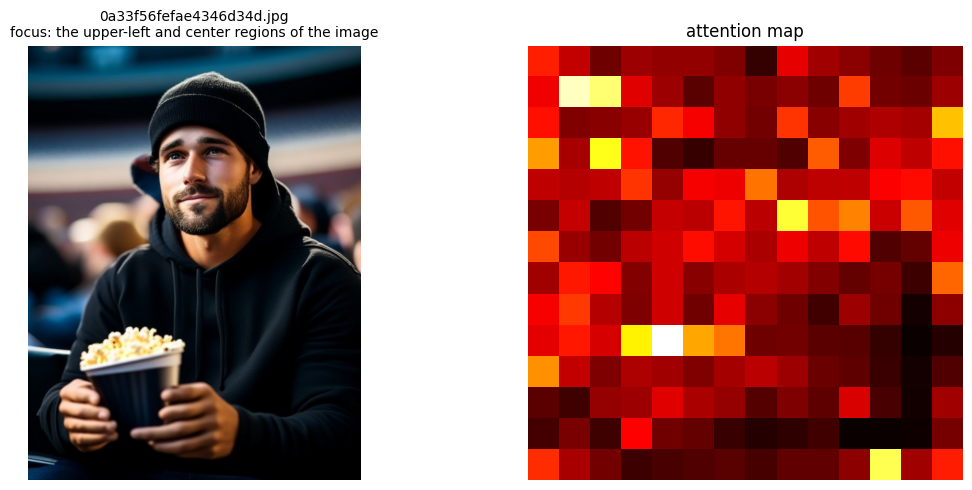


[ZERO_SHOT]
addCriterion("image", "The image appears to have some visual artifacts that suggest it may be AI-generated. Here are a few observations:

1. **Blurred Background**: The background seems slightly out of focus, which can sometimes occur in AI-generated images where the depth of field is not perfectly rendered.
2. **Lighting and Shadows**: The lighting on the person's face and the popcorn container l

[COT]
addCriterion 1: **Most Suspicious Regions**
The most suspicious regions in this image are the hands and the facial features.

1. **Hands**: The hands appear unusually smooth and lack natural creases or shadows that would be expected from real human skin.
2. **Facial Features**: The eyes and lips have a slightly unnatural sheen and lack the subtle variations in shading and highlights that are typic

[FEW_SHOT]
The image appears to be of high quality with realistic details, but there are some subtle signs that it might be AI-generated:

1. **Unnaturally smooth skin lacking p

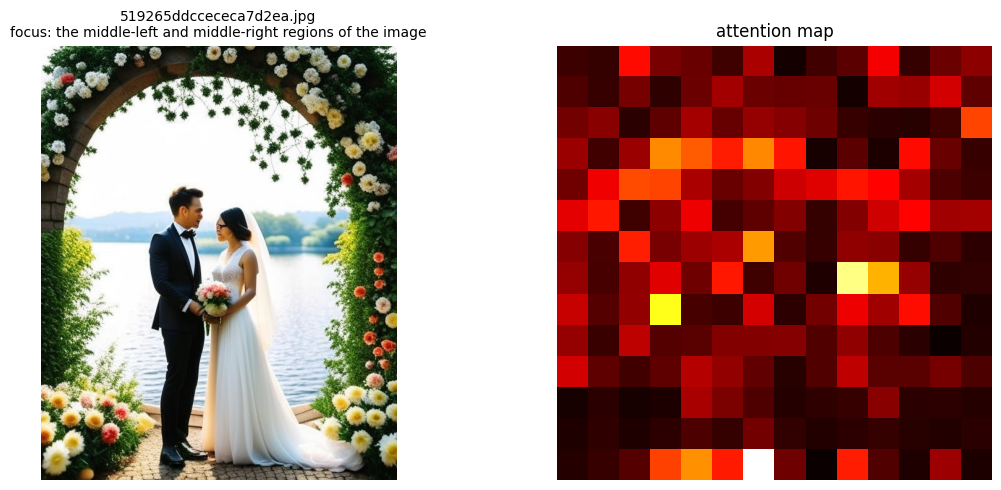


[ZERO_SHOT]
addCriterion
The image appears to have several visual artifacts that suggest it is AI-generated:

1. **Blurred Details**: The faces of the individuals in the image seem slightly blurred or lack sharpness, which can be a common issue with AI-generated images.
2. **Unnatural Lighting**: The lighting on the subjects and the background seems overly bright and uniform, which can sometimes occur in AI-g

[COT]
addCriterion 1: **Most Suspicious Regions**
- The faces of both individuals appear overly smooth and lack natural imperfections that would be expected in a real photograph.
- The shadows on their faces seem inconsistent and lack the depth and complexity typically seen in natural lighting.

[FEW_SHOT]
The image provided does not exhibit any of the common artifacts typically associated with AI-generated images. Here's a breakdown:

1. **Unnaturally smooth skin lacking pores or fine texture**: The skin of both individuals appears smooth but not overly so. There are no visible

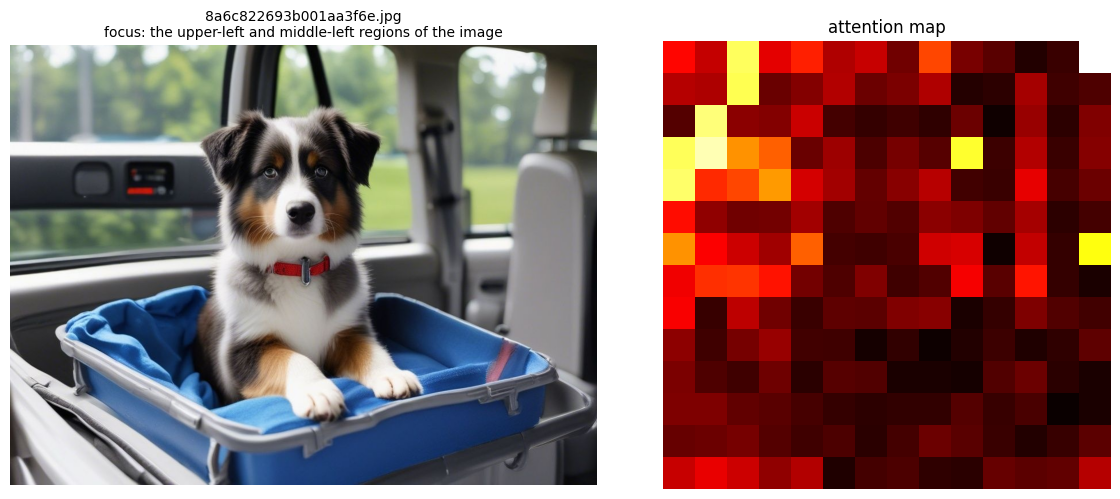


[ZERO_SHOT]
addCriterion
The image appears to have several visual artifacts that suggest it is AI-generated:

1. **Blurred Background**: The background, particularly the trees and the interior of the vehicle, seems slightly out of focus and lacks sharp detail, which can be a common issue in AI-generated images.

2. **Lighting and Shadows**: The lighting on the dog's fur and the surrounding area looks somewhat

[COT]
addCriterion 1: **Most Suspicious Regions**
The most suspicious regions in this image are the dog's fur and the overall lighting.

1. **Fur Texture**: The fur of the dog appears overly smooth and lacks natural variation in texture. Real fur typically has some visible texture, such as slight bumps or variations in density, which are not present here.
2. **Lighting**: The lighting on the dog's face 

[FEW_SHOT]
The image appears to be of high quality with no obvious signs of being AI-generated. Here's an analysis based on the common artifacts:

1. **Unnaturally smooth skin l

In [36]:
# qualitative examples
def show_example(idx):
    row = expl_df.iloc[idx]
    img = Image.open(os.path.join(images_dir, row['image_name']))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title(f'{row["image_name"]}\nfocus: {row["region_text"]}', fontsize=10)
    axes[0].axis('off')
    axes[1].imshow(attention_maps[row['test_idx']], cmap='hot')
    axes[1].set_title('attention map'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

    for pname in prompt_names:
        print(f'\n[{pname.upper()}]')
        print(row[f'expl_{pname}'][:400])
    print('\n' + '='*80)

for i in [0, 1, 2]:
    show_example(i)

reloading vit + qwen-vl for demo...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

upload an image to analyze:


Saving photo-1516708274537-6f91e34ccaf2.avif to photo-1516708274537-6f91e34ccaf2.avif

analyzing: photo-1516708274537-6f91e34ccaf2.avif

prediction: REAL (100.0% confidence)


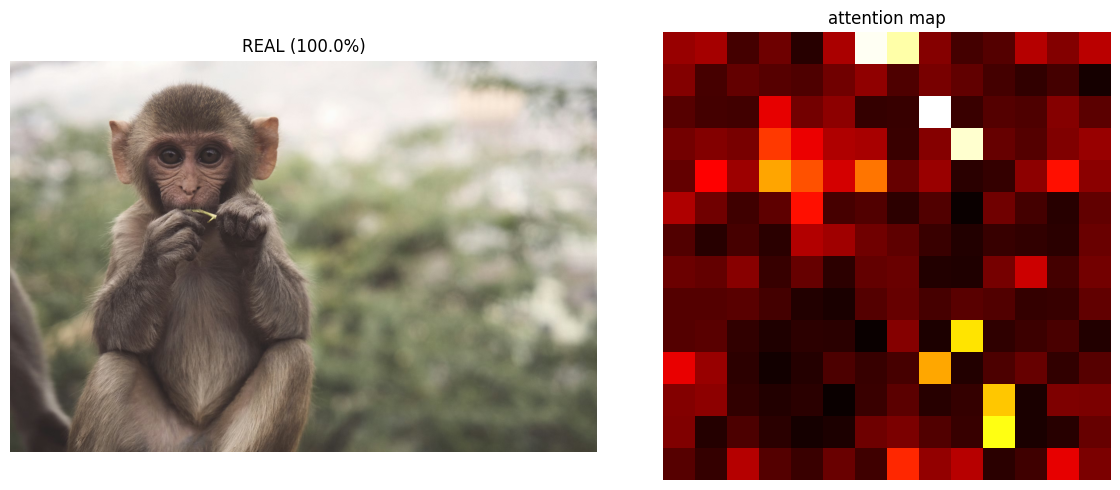

In [50]:
# full-pipeline demo with image upload
print('reloading vit + qwen-vl for demo...')
vit_model = ViTForImageClassification.from_pretrained(
    './models/vit_deepfake', attn_implementation='eager'
).to(device)
vit_model.eval()

qwen_vl = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct",
    torch_dtype=torch.bfloat16, device_map="auto", attn_implementation="sdpa"
)
qwen_vl_processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
qwen_vl_processor.tokenizer.padding_side = 'left'
qwen_vl.eval()

from torchvision import transforms as T
vit_transform = T.Compose([
    T.Resize((224, 224)), T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def clean_explanation(text):
    """strip leftover artifacts like 'addCriterion' that leak from generation"""
    for junk in ['addCriterion', 'addCriteria']:
        text = text.replace(junk, '').strip()
    if text and text[0] in '.,;:':
        text = text[1:].strip()
    return text

def deeplens(image_path):
    img = Image.open(image_path).convert('RGB')
    x = vit_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = vit_model(pixel_values=x, output_attentions=True)
    probs = torch.softmax(out.logits.float(), dim=1)[0]
    pred = probs.argmax().item()
    conf = probs[pred].item()
    label = 'FAKE' if pred == 1 else 'REAL'
    attn = out.attentions[-1].float().mean(dim=1)[0, 0, 1:].reshape(14, 14).cpu().numpy()

    print(f'\nprediction: {label} ({conf*100:.1f}% confidence)')

    explanation = None
    if pred == 1:
        region_text = attention_to_text(attn)
        prompt = PROMPTS['attention_grounded'].format(region_text=region_text)
        messages = [{"role": "user", "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": prompt}
        ]}]
        text = qwen_vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, _ = process_vision_info(messages)
        inputs = qwen_vl_processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(qwen_vl.device)
        with torch.no_grad():
            gen = qwen_vl.generate(**inputs, max_new_tokens=200, do_sample=False)
        trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, gen)]
        explanation = clean_explanation(
            qwen_vl_processor.batch_decode(trimmed, skip_special_tokens=True)[0]
        )
        print(f'attention focus: {region_text}')
        print(f'\nexplanation:\n{explanation}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img); axes[0].set_title(f'{label} ({conf*100:.1f}%)'); axes[0].axis('off')
    axes[1].imshow(attn, cmap='hot'); axes[1].set_title('attention map'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    return label, conf, explanation

# upload your own image to test
print('upload an image to analyze:')
uploaded = files.upload()
for fname in uploaded.keys():
    print(f'\n{"="*80}\nanalyzing: {fname}\n{"="*80}')
    deeplens(fname)

In [42]:
files.download('./data/explanations.csv')
files.download('./data/judge_qwen.csv')
files.download('./data/results_qwen.csv')
print('done')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

done
